lab 8

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



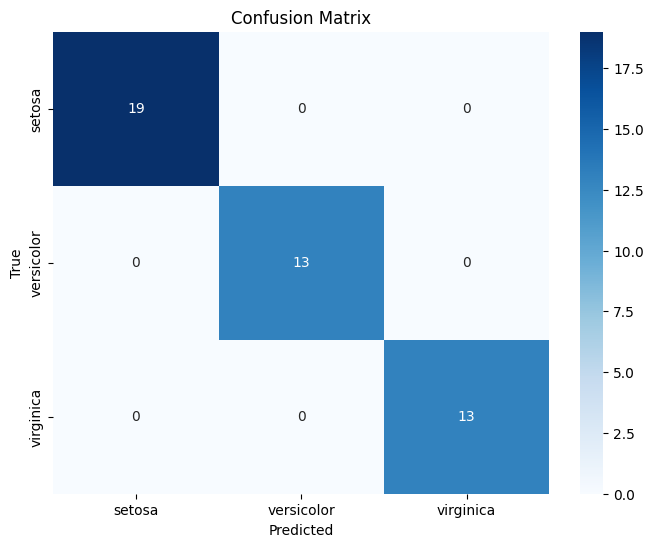

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

adaboost = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost.fit(X_train, y_train)

y_pred = adaboost.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



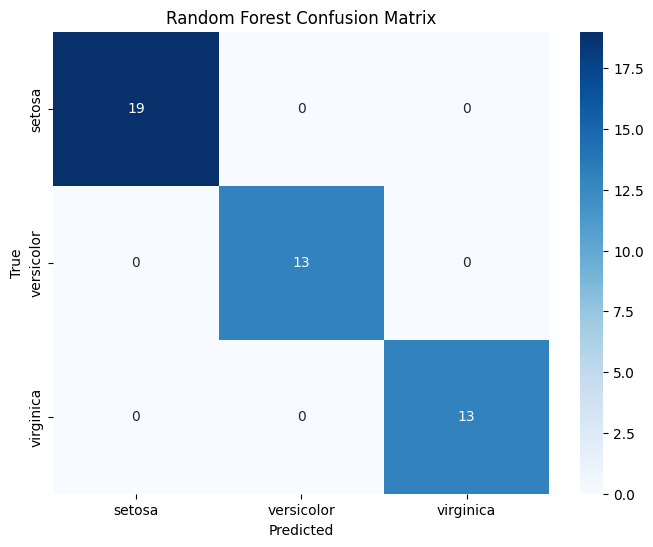

In [ ]:

from sklearn.ensemble import RandomForestClassifier


random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")
plt.show()

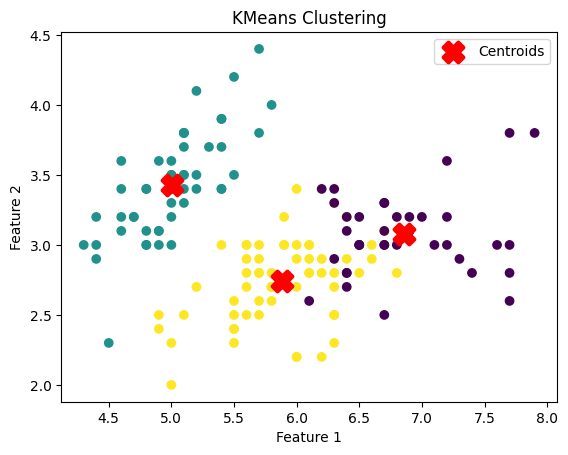

Silhouette Score: 0.551191604619592


In [ ]:

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, calinski_harabasz_score


iris = load_iris()
X = iris.data

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, linewidths=3, color='r', label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering')
plt.legend()
plt.show()

silhouette_avg = silhouette_score(X, labels)
print(f"Silhouette Score: {silhouette_avg}")



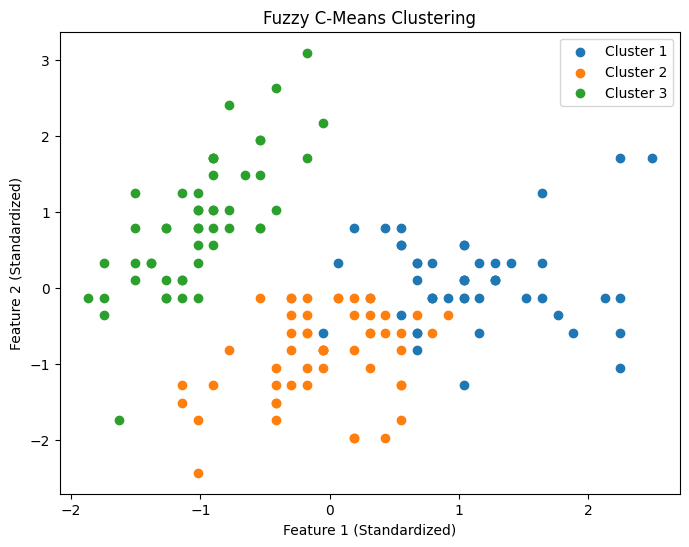

Fuzzy Partition Coefficient (PC): 0.71


In [ ]:
from sklearn.preprocessing import StandardScaler
import skfuzzy as fuzz

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmfrom sklearn.preprocessing import StandardScaler
import skfuzzy as fuzz

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 3
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T,
    c=n_clusters,
    m=2.0,
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)

fcm_labels = np.argmax(u, axis=0)

plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_scaled[fcm_labels == i, 0], X_scaled[fcm_labels == i, 1], label=f'Cluster {i + 1}')
plt.title('Fuzzy C-Means Clustering')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.show()

fcm_partition_coefficient = np.sum(u**2) / len(X_scaled)
print(f"Fuzzy Partition Coefficient (PC): {fcm_partition_coefficient:.2f}")
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.2f}")
eans(
    X_scaled.T,
    c=n_clusters,
    m=2.0,
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)

fcm_labels = np.argmax(u, axis=0)

plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_scaled[fcm_labels == i, 0], X_scaled[fcm_labels == i, 1], label=f'Cluster {i + 1}')
plt.title('Fuzzy C-Means Clustering')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.show()

fcm_partition_coefficient = np.sum(u**2) / len(X_scaled)
print(f"Fuzzy Partition Coefficient (PC): {fcm_partition_coefficient:.2f}")
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.2f}")


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agglomerative = AgglomerativeClustering(n_clusters=3)
agglomerative_labels = agglomerative.fit_predict(X)

print("Agglomerative Clustering Adjusted Rand Index:", adjusted_rand_score(y, agglomerative_labels))


Agglomerative Clustering Adjusted Rand Index: 0.7311985567707746
